# EPL Foul Win Probability Model

## Phase 1: Data Understanding

### Objective

The objective of this notebook is to understand the EPL event data before feature engineering and model development.

### Goals

- Load the datasets
- Understand the schema
- Explore event distributions
- Identify missing values
- Inspect important columns
- Identify events required for target creation

In [1]:
from pathlib import Path
import sys

# Add project root to Python path
project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import DataLoader

In [3]:
loader = DataLoader()

events, matches = loader.load_all()

2026-06-27 13:53:20,049 | INFO | Loading all datasets...
2026-06-27 13:53:20,051 | INFO | Loading events dataset...
2026-06-27 13:53:30,557 | INFO | Events dataset loaded successfully (1,313,783 rows × 49 columns)
2026-06-27 13:53:30,558 | INFO | Loading matches dataset...
2026-06-27 13:53:30,566 | INFO | Matches dataset loaded successfully (380 rows × 28 columns)
2026-06-27 13:53:30,567 | INFO | All datasets loaded successfully.


In [5]:
loader.get_dataset_info()

{'data_directory': 'C:\\Users\\91900\\Teamwork_Online\\epl-foul-prediction\\data\\raw',
 'events_file': 'C:\\Users\\91900\\Teamwork_Online\\epl-foul-prediction\\data\\raw\\epl_event_data_15.csv',
 'matches_file': 'C:\\Users\\91900\\Teamwork_Online\\epl-foul-prediction\\data\\raw\\epl_matches_15.csv',
 'events_exists': True,
 'matches_exists': True}

In [6]:
print("="*60)
print("EVENT DATASET")
print("="*60)

print(events.shape)

print()

print("="*60)
print("MATCH DATASET")
print("="*60)

print(matches.shape)

EVENT DATASET
(1313783, 49)

MATCH DATASET
(380, 28)


In [7]:
events.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
0,1,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
1,2,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
2,3,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,1,0.000000,100362ee-9311-4187-bd8a-0201d9db2565,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
3,4,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,1,0.000000,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
4,5,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,2,0.308263,1f98c89e-2326-4200-8c12-a987fdbbaf2e,...,"60.4, 43.6",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058


In [8]:
matches.head()

,Unnamed: 0,match_id,match_date,kick_off,home_score,away_score,match_status,last_updated,match_week,competition.competition_id,...,away_team.away_team_name,away_team.managers,competition_stage.id,competition_stage.name,stadium.id,stadium.name,referee.id,referee.name,referee.country.id,referee.country.name
0,1,3754058,2016-01-02,16:00:00.000,0,0,available,2021-10-29T23:44:19.940296,20,2,...,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",1,Regular Season,20,King Power Stadium,5,Andre Marriner,68,England
1,2,3754245,2015-10-17,16:00:00.000,1,0,available,2022-12-01T13:09:17.044015,9,2,...,Sunderland,"561, Sam Allardyce, NA, 1954-10-19, 68, England",1,Regular Season,33,The Hawthorns,4,Martin Atkinson,68,England
2,3,3754136,2015-12-19,18:30:00.000,1,1,available,2020-11-12T23:48:19.757269,17,2,...,Aston Villa,"92, Rémi Garde, NA, 1966-04-03, 78, France",1,Regular Season,4674,St. James'' Park,4,Martin Atkinson,68,England
3,4,3754037,2016-04-30,16:00:00.000,2,1,available,2021-07-07T17:59:57.456,36,2,...,AFC Bournemouth,"38, Eddie Howe, NA, 1977-11-29, 68, England",1,Regular Season,12,Goodison Park,7,Neil Swarbrick,68,England
4,5,3754039,2016-02-13,16:00:00.000,1,2,available,2021-07-25T18:09:51.386,26,2,...,Watford,"236, Enrique Sánchez Flores, Quique Sánchez Fl...",1,Regular Season,37,Selhurst Park,9,Robert Madley,68,England


In [9]:
events.sample(5)

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
1199564,1199565,9482a50d-d9da-4f20-a518-c673ca9dd692,1179,1,00:29:38.747,29,38,65,NaN,4f1d2a14-d0db-4e1f-a324-1117eb5bca1e,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754308
117294,117295,67bf770c-1b93-43c3-82ad-eb52a0afc546,262,1,00:06:18.999,6,18,14,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754007
429339,429340,8888ef3c-e93b-407e-9417-32cad556c13a,2062,2,00:10:41.797,55,41,145,NaN,88a2963e-7b8c-43df-adc9-93a9744990a4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754257
734793,734794,abdcb72d-2868-4ab0-b527-acbd8242f775,417,1,00:07:40.384,7,40,22,1.236545,5dbd3af0-cba4-458f-850c-de3b535016fc,...,"42.7, 72.9",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754018
991801,991802,b6410a93-35f5-4002-953d-9c869a9576af,518,1,00:12:43.749,12,43,27,0.000000,0b140445-f55a-402b-95c5-bba475fe04d2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754187


In [10]:
events.info()

<class 'pandas.DataFrame'>
RangeIndex: 1313783 entries, 0 to 1313782
Data columns (total 49 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Unnamed: 0                 1313783 non-null  int64  
 1   id                         1313783 non-null  str    
 2   index                      1313783 non-null  int64  
 3   period                     1313783 non-null  int64  
 4   timestamp                  1313783 non-null  str    
 5   minute                     1313783 non-null  int64  
 6   second                     1313783 non-null  int64  
 7   possession                 1313783 non-null  int64  
 8   duration                   973459 non-null   float64
 9   related_events             1258785 non-null  str    
 10  location                   1305706 non-null  str    
 11  under_pressure             279690 non-null   object 
 12  counterpress               42350 non-null    object 
 13  type.id                

In [11]:
matches.info()

<class 'pandas.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Unnamed: 0                    380 non-null    int64
 1   match_id                      380 non-null    int64
 2   match_date                    380 non-null    str  
 3   kick_off                      380 non-null    str  
 4   home_score                    380 non-null    int64
 5   away_score                    380 non-null    int64
 6   match_status                  380 non-null    str  
 7   last_updated                  380 non-null    str  
 8   match_week                    380 non-null    int64
 9   competition.competition_id    380 non-null    int64
 10  competition.country_name      380 non-null    str  
 11  competition.competition_name  380 non-null    str  
 12  season.season_id              380 non-null    int64
 13  season.season_name            380 non-null    

In [12]:
events.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,1313783.0,NaN,NaN,NaN,656892.0,379256.628691,1.0,328446.5,656892.0,985337.5,1313783.0
id,1313783,1313783,9153e9f4-f69c-4e04-8f64-505592e212cd,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
index,1313783.0,NaN,NaN,NaN,1740.844325,1018.108694,1.0,865.0,1729.0,2593.0,4264.0
period,1313783.0,NaN,NaN,NaN,1.493956,0.499964,1.0,1.0,1.0,2.0,2.0
timestamp,1313783,768748,00:00:00.000,2508,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minute,1313783.0,NaN,NaN,NaN,45.004,27.077315,0.0,21.0,45.0,68.0,101.0
second,1313783.0,NaN,NaN,NaN,29.250901,17.377648,0.0,14.0,29.0,44.0,59.0
possession,1313783.0,NaN,NaN,NaN,93.413354,55.111716,1.0,46.0,92.0,139.0,239.0
duration,973459.0,NaN,NaN,NaN,1.243104,3.166813,-2660.414,0.188965,1.007752,1.723463,68.176704
related_events,1258785,1207464,"13dd8a5f-4dc2-47b9-a157-a96b29fa0a29, b806491f...",5,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
matches.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,380.0,NaN,NaN,NaN,190.5,109.840794,1.0,95.75,190.5,285.25,380.0
match_id,380.0,NaN,NaN,NaN,3754161.5,109.840794,3753972.0,3754066.75,3754161.5,3754256.25,3754351.0
match_date,380,99,2015-12-26,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN
kick_off,380,12,16:00:00.000,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
home_score,380.0,NaN,NaN,NaN,1.492105,1.259242,0.0,1.0,1.0,2.0,6.0
away_score,380.0,NaN,NaN,NaN,1.207895,1.146955,0.0,0.0,1.0,2.0,6.0
match_status,380,1,available,380,NaN,NaN,NaN,NaN,NaN,NaN,NaN
last_updated,380,348,2020-07-29T05:00,9,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_week,380.0,NaN,NaN,NaN,19.5,10.980313,1.0,10.0,19.5,29.0,38.0
competition.competition_id,380.0,NaN,NaN,NaN,2.0,0.0,2.0,2.0,2.0,2.0,2.0


In [14]:
missing = (
    events.isnull()
          .sum()
          .sort_values(ascending=False)
)

missing.head(25)

pass.receipient.id           1313783
tactics.lineup               1312398
tactics.formation            1312398
dribble.outcome.id           1300062
dribble.outcome.name         1300062
duel.outcome.id              1298338
duel.outcome.name            1298338
counterpress                 1271433
ball_receipt.outcome.id      1255838
ball_receipt.outcome.name    1255838
pass.type.id                 1232192
pass.type.name               1232192
pass.outcome.name            1227543
pass.outcome.id              1227543
carry.end_location           1036834
under_pressure               1034093
pass.recipient.name           973458
pass.body_part.id             973239
pass.body_part.name           973239
pass.angle                    945164
pass.height.id                945164
pass.height.name              945164
pass.end_location             945164
pass.length                   945164
duration                      340324
dtype: int64

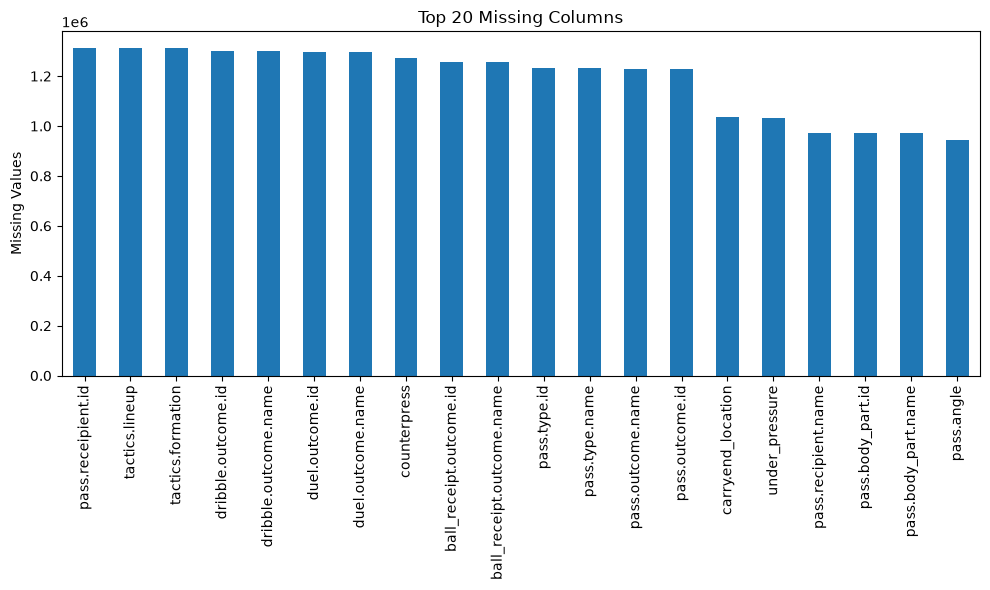

In [15]:
plt.figure(figsize=(10,6))

missing.head(20).plot(kind="bar")

plt.title("Top 20 Missing Columns")

plt.ylabel("Missing Values")

plt.tight_layout()

plt.show()

In [16]:
event_counts = (
    events["type.name"]
    .value_counts()
)

event_counts.head(20)

type.name
Pass              368619
Ball Receipt*     340324
Carry             276949
Pressure          115402
Ball Recovery      40943
Duel               32290
Clearance          21645
Block              14839
Dribble            13721
Goal Keeper        11777
Miscontrol         10786
Dispossessed       10520
Shot                9908
Foul Committed      9512
Foul Won            9112
Interception        8920
Dribbled Past       8771
Substitution        2109
Half Start          1520
Half End            1520
Name: count, dtype: int64

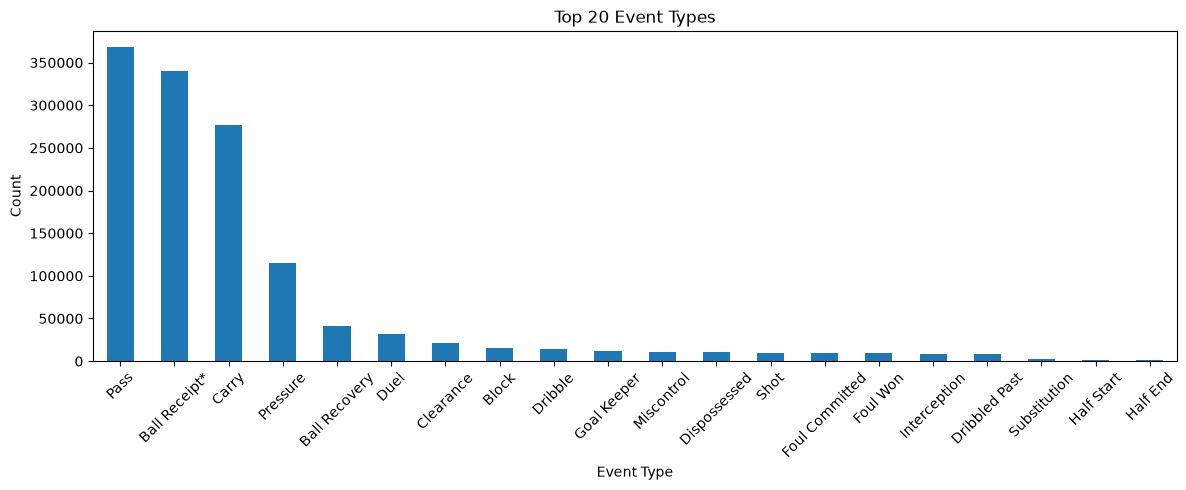

In [17]:
plt.figure(figsize=(12,5))

event_counts.head(20).plot(
    kind="bar"
)

plt.title("Top 20 Event Types")

plt.ylabel("Count")

plt.xlabel("Event Type")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [18]:
important_events = events[
    events["type.name"].isin(
        [
            "Ball Receipt*",
            "Ball Recovery",
            "Foul Won"
        ]
    )
]

important_events["type.name"].value_counts()

type.name
Ball Receipt*    340324
Ball Recovery     40943
Foul Won           9112
Name: count, dtype: int64

In [19]:
important_events.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
5,6,1f98c89e-2326-4200-8c12-a987fdbbaf2e,6,1,00:00:02.061,0,2,2,NaN,2ca23eea-a984-47e4-8243-8f00880ad1c9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
8,9,8764f645-0544-426e-9bef-764dcf13f019,9,1,00:00:03.010,0,3,2,NaN,0fee7719-7e69-49c5-be81-3f2b77da604e,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
10,11,4e43a985-9566-4762-868f-c992de243bd6,11,1,00:00:05.465,0,5,2,NaN,6362aa69-892f-4d11-8644-21a680ea7c66,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
13,14,a4eb31c9-6417-4a65-9f71-b3aeece1758e,14,1,00:00:07.941,0,7,2,NaN,56da36e4-8b0d-4596-ba46-1d944c3d3f04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
16,17,4b427f4b-296d-4967-a419-b6b480fe50e2,17,1,00:00:10.462,0,10,2,NaN,bcfea2e3-9736-4975-be28-ef2c9d693fa7,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058


In [20]:
columns = [
    "match_id",
    "id",
    "index",
    "period",
    "timestamp",
    "minute",
    "second",
    "type.name",
    "possession",
    "player.id",
    "team.id",
    "location"
]

events[columns].head()

,match_id,id,index,period,timestamp,minute,second,type.name,possession,player.id,team.id,location
0,3754058,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,Starting XI,1,NaN,22,NaN
1,3754058,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,Starting XI,1,NaN,28,NaN
2,3754058,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,Half Start,1,NaN,28,NaN
3,3754058,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,Half Start,1,NaN,22,NaN
4,3754058,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,Pass,2,3343.0,28,"61, 40.1"


In [25]:
events["under_pressure"].value_counts(dropna=False)

under_pressure
NaN     1034093
True     279690
Name: count, dtype: int64

In [26]:
events.groupby("match_id").size().describe()

count     380.000000
mean     3457.323684
std       284.593378
min      2670.000000
25%      3264.000000
50%      3454.000000
75%      3644.250000
max      4264.000000
dtype: float64

In [27]:
events["possession"].describe()

count    1.313783e+06
mean     9.341335e+01
std      5.511172e+01
min      1.000000e+00
25%      4.600000e+01
50%      9.200000e+01
75%      1.390000e+02
max      2.390000e+02
Name: possession, dtype: float64

In [28]:
matches.columns.tolist()

['Unnamed: 0',
 'match_id',
 'match_date',
 'kick_off',
 'home_score',
 'away_score',
 'match_status',
 'last_updated',
 'match_week',
 'competition.competition_id',
 'competition.country_name',
 'competition.competition_name',
 'season.season_id',
 'season.season_name',
 'home_team.home_team_id',
 'home_team.home_team_name',
 'home_team.managers',
 'away_team.away_team_id',
 'away_team.away_team_name',
 'away_team.managers',
 'competition_stage.id',
 'competition_stage.name',
 'stadium.id',
 'stadium.name',
 'referee.id',
 'referee.name',
 'referee.country.id',
 'referee.country.name']

# Summary

## Dataset Overview

Two datasets were successfully loaded and validated for this project:

| Dataset | Rows | Columns |
|---------|------:|--------:|
| EPL Event Data | 1,313,783 | 49 |
| EPL Match Data | 380 | 28 |

The event dataset contains detailed event-level information for every action that occurred during the 380 Premier League matches, while the match dataset provides match-level metadata such as scores, competition details, teams, referees, and venue information.

---

## Data Quality Assessment

### Missing Values

The event dataset contains several columns with a high percentage of missing values. Most of these fields correspond to event-specific attributes that are only populated for particular event types.

Examples include:

- `pass.recipient.id`
- `tactics.lineup`
- `dribble.outcome.*`
- `duel.outcome.*`
- `ball_receipt.outcome.*`
- `carry.end_location`
- `under_pressure`

These missing values are expected because they are conditional on the event type rather than indicating poor data quality.

The match dataset contains no significant missing values and appears complete.

---

## Event Distribution

The most frequently occurring event types are:

| Event Type | Approximate Count |
|------------|------------------:|
| Pass | 368,619 |
| Ball Receipt* | 340,324 |
| Carry | 276,949 |
| Pressure | 115,402 |
| Ball Recovery | 40,943 |
| Duel | 32,290 |

This distribution reflects the natural flow of football matches, where passing and ball receipts dominate possession sequences.

---

## Events Relevant to the Prediction Task

The objective of this project is to predict whether a player will win a foul after receiving or recovering possession.

The primary event types involved in target creation are:

| Event | Count |
|--------|------:|
| Ball Receipt* | 340,324 |
| Ball Recovery | 40,943 |
| Foul Won | 9,112 |

These events will form the basis for constructing the supervised learning target in the next phase.

---

## Important Variables Identified

The following variables were identified as essential for building the modeling dataset:

- `match_id`
- `id`
- `index`
- `period`
- `timestamp`
- `minute`
- `second`
- `possession`
- `type.name`
- `player.id`
- `team.id`
- `location`
- `under_pressure`

These variables will be used to reconstruct possession sequences, engineer spatial and temporal features, and generate the prediction target.

---

## Initial Observations

- The event data is well structured and contains detailed sequential information.
- Event ordering can be reconstructed using `match_id`, `period`, and `index`.
- Possession identifiers provide a natural grouping for analyzing sequences of play.
- Spatial information (`location`) enables future feature engineering based on field position.
- Approximately 9,100 "Foul Won" events are available, indicating a moderately imbalanced binary classification problem.

---

## Next Steps

The next phase of the project will focus on constructing the supervised learning dataset by:

1. Creating the target variable.
2. Identifying Ball Receipt and Ball Recovery events.
3. Determining whether a Foul Won occurs later within the same possession.
4. Generating one training instance for each possession start.
5. Saving the processed modeling dataset to the `data/processed` directory.

The resulting dataset will serve as the foundation for feature engineering and predictive model development in subsequent phases.